# Hybrid framework - PPO Training

In [ ]:
import os
import io
import random
import math
import torch
import json
import pickle
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter
from ultralytics import YOLO 
import torch.nn.functional as F
from tqdm import tqdm
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import probtools
from mylib import ppo  
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import NUM_CLASSES, DIRICHLET_PRIOR
from constants import ACTIONS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [2]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration 
simulation = simulations[3]
 
# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Load bins per class
with open('simulation-data/object-classes-bins.json', 'r') as f:
    classes_bins = json.load(f)

# Load indoor objects
with open('simulation-data/indoor-objects.json', 'r') as f:
    data = json.load(f)
    indoor_objects = [list(item.values())[0] for item in data["indoor_classes"]]

TARGET_OBJECT_CLASS_ID = indoor_objects.index(TARGET_OBJECT)

# Load Dirichlet priors
with open('simulation-data/dirichlet-alpha-priors-augmented.pkl', 'rb') as f:
    dirichlet_priors = pickle.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 by NVIDIA Corporation


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[10:12:04:143350]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/RoboTHOR/FloorPlan_Train3_4.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
[10:12:04:635384]:[Warning]:[Sim

OpenGL version: 4.6.0 NVIDIA 535.230.02
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisI

In [3]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = simsettings.create_navmesh_settings(AGENT_HEIGHT, AGENT_RADIUS, max_climb=0.2, max_slope=45.0, include_static_objects=True)

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map, topdown_resolution = myutils.process_raw_topdown_map(topdown_map)

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map, grid_resolution = myutils.process_raw_grid_map(grid_map, sim.pathfinder)

# Find free and occupied cells in the grid map
grid_free_cells, map_free_cells, world_free_coords = myutils.find_free_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)
grid_occ_cells, map_occ_cells, world_occ_coords = myutils.find_occupied_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)

# Merge free and occupied positions into a single list
grid_cells = grid_free_cells + grid_occ_cells
map_cells = map_free_cells + map_occ_cells
world_coords = world_free_coords + world_occ_coords

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)

# Build binary int grid map (0: free, 1: occupied)
grid_binary_map = np.zeros_like(grid_map, dtype=np.int32)
# Filter out-of-bounds cells
valid_occ_cells = [
	(x, y) for (x, y) in grid_occ_cells
	if 0 <= x < grid_binary_map.shape[0] and 0 <= y < grid_binary_map.shape[1]
]
grid_binary_map[tuple(np.array(valid_occ_cells).T)] = 1
grid_binary_map = grid_binary_map[..., 0] 


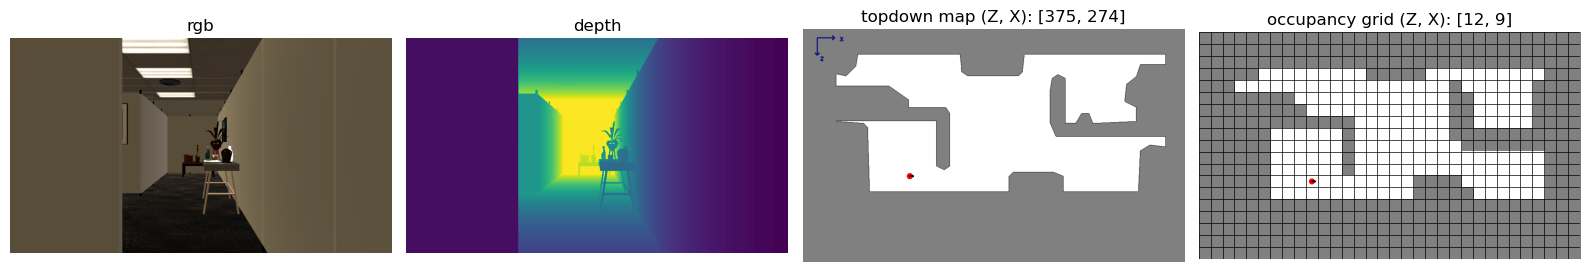

In [4]:
# Initialize belief map: NUM_CLASSES + 1 for the background 
belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_free_cells)
idx = grid_free_cells.index(grid_position)
world_position = world_free_coords[idx]
map_position = map_free_cells[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = world_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius = (topdown_radius, grid_radius)
agent_positions = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb, depth = observations["color_sensor"], observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

In [ ]:
# PPO Hyperparameters
gamma = 0.99
gae_lambda = 0.95
clip_range = 0.2
n_steps = 1024
batch_size = 256
n_epochs = 4
lr = 3e-4
ent_coef = 0.05
vf_coef = 0.5
max_grad_norm = 0.5
max_episodes = 100

# Max iterations per episode
MAX_ITER = int(MAX_ITER_COEF * num_free_cells)

# Initialize PPO Agent
NUM_ACTIONS = len(ACTIONS)   # forward, left, right
policy_net = ppo.PPOAgent(in_channels=6, n_actions=NUM_ACTIONS, obs_shape=(6,19,32))

if os.path.exists("ppo_policy.pth"):
    policy_net.net.load_state_dict(torch.load("ppo_policy.pth"))
    print("Loaded PPO policy from checkpoint.")
else:
    print("Training from scratch.")

Loaded PPO policy from checkpoint.


In [6]:
# ================================
# PPO Training Loop
# ================================

# Counters
global_step = 0
turn_right_actions = 0
turn_left_actions = 0
move_forward_actions = 0

# Track performance
episode_lengths = []
episode_location_errors = [] 
episode_travelled_distances = []
episode_success_flags = []
episode_rewards = []

# Training loop
for episode in tqdm(range(max_episodes)):

    # Metrics init
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")
    episode_reward = 0.0

    # Init agent state 
    grid_position = random.choice(grid_free_cells)
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]
    agent_positions = (map_position, grid_position)

    agent_yaw = random.choice([0, 90, 180, 270])
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)
    
    # Reward struct init
    visited_cells = set([tuple(grid_position)])
    prev_phi = 0.0

    # Belief map initialization
    belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR 
                   for _ in range(grid_resolution[1])] 
                   for _ in range(grid_resolution[0])]

    # First observation
    obs = ppo.build_fullmap_obs(
        np.array(np.array(belief_map, dtype=np.float32)), 
        TARGET_OBJECT_CLASS_ID, 
        grid_binary_map, 
        tuple(grid_position), 
        math.radians(agent_yaw), 
        NUM_CLASSES+1
    )

    done = False
    while not done and num_actions < MAX_ITER:

        # Store previous belief map for reward computation
        belief_map_prev = [[belief_map[i][j].copy() for j in range(grid_resolution[1])] for i in range(grid_resolution[0])]
        prev_grid_position = grid_position.copy()

        # Select action from PPO
        action, logp, value = policy_net.select_action(obs)
        action_str = list(ACTIONS)[action]

        # Print
        # print(f"Action: ", action_str, " ", action)
        # print(f"Value: ", value)

        # Update action counters
        if action_str == "turn_right":
            turn_right_actions += 1
            turning_action = True
        elif action_str == "turn_left":
            turn_left_actions += 1
            turning_action = True
        elif action_str == "move_forward":
            move_forward_actions += 1
            turning_action = False

        # Perform action
        collided = not simtools.is_action_valid(action_str, grid_position, agent_yaw, grid_free_cells)
        if not collided:
            grid_position, agent_yaw = simtools.perform_action(action_str, grid_position, agent_yaw)

        # Add cell to the visited set
        visited_cells.add(tuple(grid_position))

        # Update agent state in sim
        idx = grid_free_cells.index(grid_position)
        map_position, world_position = map_free_cells[idx], world_free_coords[idx]
        agent_positions = (map_position, grid_position)
        agent_quart = myutils.yaw_to_quaternion(agent_yaw)

        travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)
        agent_state.position = world_position
        agent_state.rotation = agent_quart
        agent.set_state(agent_state)

        # Sensor obs + YOLO detection
        obs_dict = sim.get_sensor_observations(0)
        rgb, depth = obs_dict["color_sensor"], obs_dict["depth_sensor"]
        results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40,
                                     verbose=False, max_det=10)
        detections = simtools.parse_yolo_detections(results)
        simtools.merge_rgb_yolo_outputs(rgb, detections)
        target_found, target_bbox = simtools.was_target_found(
            TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD
        )

        # Entropy before update
        p_prev = ppo.dirichlet_mean(np.array(belief_map))
        entropy_prev = ppo.categorical_entropy(p_prev) / np.log(NUM_CLASSES+1)

        # Belief map update (same logic as before, just keep using your probtools/kaplan)
        processed_cells = []
        for det in detections:
            box, class_id, confidence, name, prob_vector = det['box'], det['class_id'], det['confidence'], det['name'], det['prob_vector']
            scale = myutils.compute_bbox_scale(box, rgb)
            center_x, center_y = simtools.get_box_center(box)
            depth_value = depth[center_y, center_x]
            camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
            object_position = simtools.compute_real_world_position_from_pixel(
                camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics
            )
            object_map_position, object_grid_position = simtools.get_2d_coords(
                object_position, topdown_resolution, grid_resolution, sim.pathfinder
            )
            if object_grid_position in grid_free_cells:
                object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

            if tuple(object_grid_position) not in processed_cells:
                processed_cells.append(tuple(object_grid_position))

            likelihood_vector = probtools.compute_likelihood_vector(
                prob_vector, scale, dirichlet_priors, classes_bins
            )
            grid_x, grid_y = object_grid_position
            belief_map[grid_x][grid_y] = probtools.kaplan_update(
                belief_map[grid_x][grid_y], likelihood_vector
            )

        rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
        visible_occ_cells = simtools.compute_visible_occ_cells(
            rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics
        )
        for cell in visible_occ_cells:
            if tuple(cell) not in processed_cells:
                grid_x, grid_y = cell
                distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)
                likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)
                belief_map[grid_x][grid_y] = probtools.kaplan_update(
                    belief_map[grid_x][grid_y], likelihood_vector
                )

        # Check stop condition from belief map
        if not target_found:
            target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(
                belief_map, grid_cells, TARGET_OBJECT_CLASS_ID, PSEUDO_COUNT_THRESHOLD
            )

        # Build next observation
        next_obs = ppo.build_fullmap_obs(
            np.array(np.array(belief_map, dtype=np.float32)), 
            TARGET_OBJECT_CLASS_ID, 
            grid_binary_map,
            tuple(grid_position), 
            math.radians(agent_yaw), 
            NUM_CLASSES+1
        )

        # # --- Compute reward ---
        # p_new = ppo.dirichlet_mean(np.array(belief_map))
        # entropy_new = ppo.categorical_entropy(p_new) / np.log(NUM_CLASSES+1)

        # # frustum = simtools.compute_frustum_mask(grid_map, grid_position, agent_yaw)  # you’ll need a mask func

        # reward = ppo.compute_reward(
        #     target_found=target_found,
        #     collided=collided,
        #     new_cell=is_cell_newly_visited,
        #     turning_action=turning_action,
        #     entropy_prev=entropy_prev,
        #     entropy_new=entropy_new
        # )


        # Build masked fields from your belief (AFTER you compute p and entropy)
        p_prev_all = ppo.dirichlet_mean(np.array(belief_map_prev))          # (H,W,K)
        p_new_all  = ppo.dirichlet_mean(np.array(belief_map))               # (H,W,K)
        p_prev = p_prev_all[..., TARGET_OBJECT_CLASS_ID].astype(np.float32)
        p_new  = p_new_all[..., TARGET_OBJECT_CLASS_ID].astype(np.float32)

        H_prev = ppo.categorical_entropy(p_prev_all) / np.log(NUM_CLASSES+1)
        H_new  = ppo.categorical_entropy(p_new_all)  / np.log(NUM_CLASSES+1)

        # zero on free
        p_prev_occ = p_prev * grid_binary_map
        p_new_occ  = p_new  * grid_binary_map
        H_prev_occ = H_prev * grid_binary_map
        H_new_occ  = H_new  * grid_binary_map

        # reward (keep a visited_set per episode and a prev_phi scalar)
        reward, prev_phi, rinfo = rewards_ppo.compute_reward(
            target_found=target_found,
            collided=collided,
            prev_agent_rc=prev_grid_position,
            agent_rc=grid_position,
            occupancy=grid_binary_map,
            p_target_occ_prev=p_prev_occ,
            entropy_occ_prev=H_prev_occ,
            p_target_occ_new=p_new_occ,
            entropy_occ_new=H_new_occ,
            gamma=gamma,
            visited_set=visited_cells,
            prev_phi=prev_phi,
            cfg=rewards_ppo.RewardConfig()
        )

        # # Print
        # print(f"Reward: ", reward)
        # print(f"Info: ", rinfo)
        # simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

        done = target_found or num_actions >= MAX_ITER
        episode_reward += reward
        num_actions += 1
        global_step += 1

        # Store in PPO buffer
        policy_net.store(obs, action, reward, done, logp, value)

        # Advance state
        obs = next_obs

        # Every n_steps update PPO
        if global_step % n_steps == 0:
            # bootstrap last value
            _, v_last = policy_net.net(torch.from_numpy(obs).unsqueeze(0).to(policy_net.device))
            policy_net.buffer.compute_advantages(float(v_last.item()), gamma, gae_lambda)
            policy_net.update()


    # Metrics bookkeeping
    episode_lengths.append(num_actions)
    episode_location_errors.append(location_error)
    episode_travelled_distances.append(travelled_distance)
    episode_success_flags.append(target_found)
    episode_rewards.append(episode_reward)

# Save trained PPO model
torch.save(policy_net.net.state_dict(), "ppo_policy.pth")


100%|██████████| 100/100 [26:51<00:00, 16.12s/it]




Final Statistics after 100 episodes:
Total actions taken: 13190
Total episodes: 100
Total target found: 13
Success rate: 13.00%
Average episode length: 131.90 actions
Average location error: inf m
Average travelled distance: 0.00 m
Average episode reward: -19.94
Turn right actions: 13186
Turn left actions: 4
Move forward actions: 0


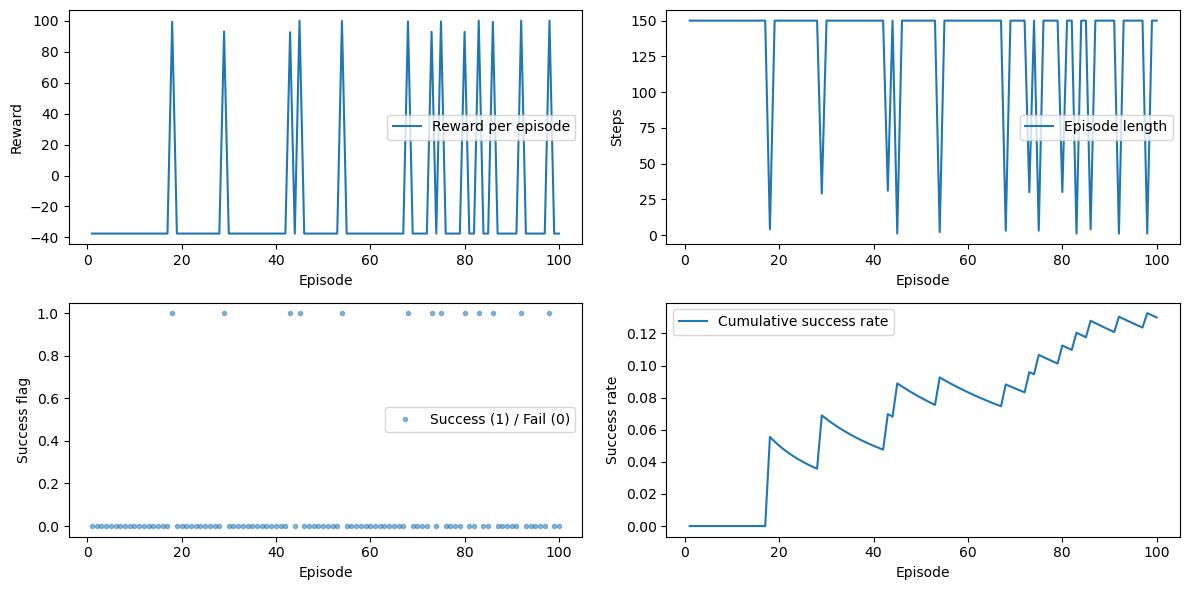

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Final Statistics ---
print(f"\n\nFinal Statistics after {max_episodes} episodes:")

print(f"Total actions taken: {sum(episode_lengths)}")
print(f"Total episodes: {len(episode_lengths)}")
print(f"Total target found: {sum(episode_success_flags)}")
print(f"Success rate: {100.0 * np.mean(episode_success_flags):.2f}%")

if len(episode_lengths) > 0:
    print(f"Average episode length: {np.mean(episode_lengths):.2f} actions")
if len(episode_location_errors) > 0:
    print(f"Average location error: {np.mean(episode_location_errors):.3f} m")
if len(episode_travelled_distances) > 0:
    print(f"Average travelled distance: {np.mean(episode_travelled_distances):.2f} m")
if len(episode_rewards) > 0:
    print(f"Average episode reward: {np.mean(episode_rewards):.2f}")

print(f"Turn right actions: {turn_right_actions}")
print(f"Turn left actions: {turn_left_actions}")
print(f"Move forward actions: {move_forward_actions}")

# --- Plot curves ---
episodes = np.arange(1, len(episode_rewards)+1)

plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.plot(episodes, episode_rewards, label="Reward per episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()

plt.subplot(2,2,2)
plt.plot(episodes, episode_lengths, label="Episode length")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.legend()

plt.subplot(2,2,3)
plt.plot(episodes, episode_success_flags, '.', label="Success (1) / Fail (0)", alpha=0.5)
plt.xlabel("Episode")
plt.ylabel("Success flag")
plt.legend()

plt.subplot(2,2,4)
plt.plot(episodes, np.cumsum(episode_success_flags)/episodes, label="Cumulative success rate")
plt.xlabel("Episode")
plt.ylabel("Success rate")
plt.legend()

plt.tight_layout()
plt.show()


In [8]:
sim.close()  # Close the simulator